# Phase 3 — Random-Init Frozen Baseline

Take the same modified ResNet-18, leave its weights at random init, freeze
everything, and linear-probe on CIFAR-10. This is the true lower bound:
it measures the accuracy you can get from architectural prior alone
(before any training of any kind).

Checkpoint is saved every epoch so the probe can resume if interrupted.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    CIFAR10_MEAN, CIFAR10_STD,
    get_device, get_cifar_resnet18, get_eval_transform, knn_monitor,
)

# Toggle: set False for the full 100-epoch probe run.
SMOKE_TEST = False

cfg = dict(
    batch_size   = 256,
    epochs       = 5 if SMOKE_TEST else 100,     # linear probe epochs (same as Phase 1)
    lr           = 1e-3,
    weight_decay = 1e-6,
    seed         = 42,
    num_workers  = 0,
    data_root    = './data',
    knn_k        = 20,
    ckpt_path    = 'models/random_baseline_probe.pth' if not SMOKE_TEST else 'models/random_smoke_probe.pth',
    backbone_path= 'models/random_baseline_backbone.pth' if not SMOKE_TEST else 'models/random_smoke_backbone.pth',
    log_path     = 'results/random_baseline_linear_probe.json' if not SMOKE_TEST else 'results/random_smoke_linear_probe.json',
    fig_path     = 'figures/random_baseline_probe_curve.png' if not SMOKE_TEST else 'figures/random_smoke_probe_curve.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])

device = get_device()
print('Device:', device)
print('Config:', cfg)


Device: privateuseone:0
Config: {'batch_size': 256, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-06, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'knn_k': 20, 'ckpt_path': 'models/random_baseline_probe.pth', 'backbone_path': 'models/random_baseline_backbone.pth', 'log_path': 'results/random_baseline_linear_probe.json', 'fig_path': 'figures/random_baseline_probe_curve.png'}


In [2]:
# --- Cell 2: Data Loading ---
# Linear probe uses EVAL transform (no augmentation) on both train and test
# to match Phase 1's protocol exactly.
eval_transform = get_eval_transform(32)
train_ds = CIFAR10(cfg['data_root'], train=True,  download=True, transform=eval_transform)
test_ds  = CIFAR10(cfg['data_root'], train=False, download=True, transform=eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=cfg['batch_size'], shuffle=True,
    num_workers=cfg['num_workers'], pin_memory=False, drop_last=False,
)
test_loader = DataLoader(
    test_ds, batch_size=512, shuffle=False,
    num_workers=cfg['num_workers'], pin_memory=False,
)
# No-shuffle memory loader for the kNN monitor
memory_loader = DataLoader(
    train_ds, batch_size=512, shuffle=False,
    num_workers=cfg['num_workers'], pin_memory=False,
)
print(f'train={len(train_ds)} | test={len(test_ds)}')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
train=50000 | test=10000


In [3]:
# --- Cell 3: Random-init backbone (frozen) ---
# Fresh modified ResNet-18; NEVER trained. Save once so the same weights can be
# re-used by Phase 8 transfer experiments.
backbone = get_cifar_resnet18().to(device)
for p in backbone.parameters(): p.requires_grad = False
backbone.eval()

os.makedirs('models', exist_ok=True)
if not os.path.exists(cfg['backbone_path']):
    torch.save({'state_dict': backbone.state_dict(), 'seed': cfg['seed']},
               cfg['backbone_path'])
    print(f"Saved frozen random backbone to {cfg['backbone_path']}")
else:
    ck = torch.load(cfg['backbone_path'], map_location='cpu', weights_only=False)
    backbone.load_state_dict(ck['state_dict']); backbone.to(device); backbone.eval()
    print(f"Loaded existing frozen random backbone from {cfg['backbone_path']} (seed={ck.get('seed')})")

n_params = sum(p.numel() for p in backbone.parameters())
print(f'Backbone params: {n_params/1e6:.2f}M (all frozen)')


Loaded existing frozen random backbone from models/random_baseline_backbone.pth (seed=42)
Backbone params: 11.17M (all frozen)


In [4]:
# --- Cell 4: kNN accuracy on frozen random features ---
# Should give somewhere around 30-40% — far above 10% random guess, because
# random CNN features still have useful architectural priors.
acc = knn_monitor(backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
print(f'kNN top-1 accuracy (frozen random backbone): {acc*100:.2f}%  (chance = 10%)')
random_knn_acc = acc


kNN top-1 accuracy (frozen random backbone): 39.95%  (chance = 10%)


In [5]:
# --- Cell 5: Linear Probe (fixed protocol, resumable) ---
# Fixed protocol matches Phase 1 exactly: Adam lr=1e-3, wd=1e-6, 100 epochs,
# bs=256, full train set, frozen backbone.
FORCE_RESTART = False

classifier = nn.Linear(512, 10).to(device)
optimizer  = torch.optim.Adam(classifier.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_sec': []}
start_epoch = 1

if (not FORCE_RESTART) and os.path.exists(cfg['ckpt_path']):
    ckpt = torch.load(cfg['ckpt_path'], map_location='cpu', weights_only=False)
    classifier.load_state_dict(ckpt['classifier_state']); classifier.to(device)
    if 'optimizer_state' in ckpt: optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'log' in ckpt: log = ckpt['log']
    start_epoch = ckpt.get('epoch', 0) + 1
    print(f"RESUMING probe from epoch {start_epoch} (done {ckpt.get('epoch', 0)}/{cfg['epochs']}).", flush=True)
else:
    print(f"Starting fresh. Classifier ckpt at {cfg['ckpt_path']}.", flush=True)

@torch.no_grad()
def _eval_test():
    classifier.eval()
    correct = total = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        h = backbone(x)
        pred = classifier(h).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return correct / total

for epoch in range(start_epoch, cfg['epochs']+1):
    classifier.train()
    t0 = time.time()
    loss_sum = corr = tot = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{cfg["epochs"]}', leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            h = backbone(x)
        logits = classifier(h)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_sum += float(loss.detach().cpu()) * y.size(0)
        corr += (logits.argmax(1) == y).sum().item()
        tot  += y.size(0)
    train_loss = loss_sum/tot
    train_acc  = corr/tot
    test_acc   = _eval_test()
    dt = time.time() - t0
    log['epoch'].append(epoch)
    log['train_loss'].append(train_loss)
    log['train_acc'].append(train_acc)
    log['test_acc'].append(test_acc)
    log['epoch_sec'].append(dt)
    if epoch == 1 or epoch % 5 == 0 or epoch == cfg['epochs']:
        print(f'[epoch {epoch:3d}/{cfg["epochs"]}] loss={train_loss:.4f} train={train_acc*100:.2f}% test={test_acc*100:.2f}%  time={dt:.1f}s', flush=True)

    tmp_path = cfg['ckpt_path'] + '.tmp'
    torch.save({
        'epoch': epoch,
        'classifier_state': classifier.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'log': log,
        'config': cfg,
    }, tmp_path)
    os.replace(tmp_path, cfg['ckpt_path'])

# Final compact result file (matches Phase 1 schema)
final = {
    'final_test_acc': log['test_acc'][-1],
    'best_test_acc':  max(log['test_acc']),
    'random_knn_acc': random_knn_acc,
    'curve': log,
    'smoke_test': SMOKE_TEST,
}
os.makedirs('results', exist_ok=True)
with open(cfg['log_path'], 'w') as f: json.dump(final, f, indent=2)

print()
print(f"Random-init linear probe | final test acc = {final['final_test_acc']*100:.2f}%  best = {final['best_test_acc']*100:.2f}%")
print(f"kNN on same backbone     | {random_knn_acc*100:.2f}%")
print('Saved', cfg['log_path'])


RESUMING probe from epoch 27 (done 26/100).


Epoch 27/100:   0%|          | 0/196 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 28/100:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 29/100:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/196 [00:00<?, ?it/s]

[epoch 100/100] loss=1.6232 train=42.90% test=41.39%  time=10.9s

Random-init linear probe | final test acc = 41.39%  best = 41.76%
kNN on same backbone     | 39.95%
Saved results/random_baseline_linear_probe.json


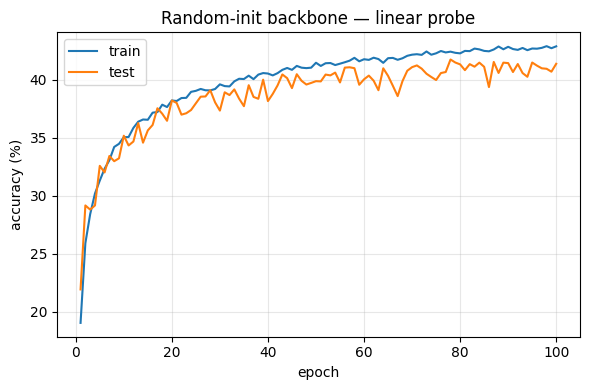

Saved figures/random_baseline_probe_curve.png


In [6]:
# --- Cell 6: Probe learning curve ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(log['epoch'], [a*100 for a in log['train_acc']], label='train')
ax.plot(log['epoch'], [a*100 for a in log['test_acc']],  label='test')
ax.set_xlabel('epoch'); ax.set_ylabel('accuracy (%)')
ax.set_title('Random-init backbone — linear probe')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig(cfg['fig_path'], dpi=150)
plt.show()
print('Saved', cfg['fig_path'])


In [7]:
# --- Cell 7: Three-way comparison (SSL vs SL vs Random) ---
def _load(path, key):
    p = Path(path)
    if not p.exists():
        return None
    d = json.loads(p.read_text())
    return d.get(key)

rand_final = log['test_acc'][-1]
rand_best  = max(log['test_acc'])
ssl_final  = _load('results/simclr_baseline_linear_probe.json', 'final_test_acc')
ssl_best   = _load('results/simclr_baseline_linear_probe.json', 'best_test_acc')
sl_log     = _load('results/supervised_baseline_log.json', 'test_acc')
sl_final   = sl_log[-1] if sl_log else None
sl_best    = max(sl_log) if sl_log else None

def _fmt(x): return f'{x*100:.2f}%' if x is not None else '   n/a '

print('CIFAR-10 test accuracy')
print('-' * 48)
print(f"{'model':<28}  {'final':>8}  {'best':>8}")
print(f"{'Random-init + probe':<28}  {_fmt(rand_final):>8}  {_fmt(rand_best):>8}")
print(f"{'SimCLR + probe':<28}  {_fmt(ssl_final):>8}  {_fmt(ssl_best):>8}")
print(f"{'Supervised':<28}  {_fmt(sl_final):>8}  {_fmt(sl_best):>8}")
print()
print(f'kNN on random backbone: {random_knn_acc*100:.2f}%')


CIFAR-10 test accuracy
------------------------------------------------
model                            final      best
Random-init + probe             41.39%    41.76%
SimCLR + probe                  86.34%    86.70%
Supervised                      91.47%    92.54%

kNN on random backbone: 39.95%
